In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sn
import spacy
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import os

In [ ]:
 # Reading in the json file
df = pd.read_json('/content/Dataset.zip', lines=True)[['headline','category']]
df.head()

,headline,category
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY
3,The Funniest Tweets From Parents This Week (Se...,PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS


# New Section

In [ ]:
df.category.value_counts()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [ ]:
 # Select only rows where the category is in a list of desired values
 desired_categories = ['CRIME', 'COMEDY', 'WEDDINGS', 'SPORTS']
 df_new = df[df['category'].isin(desired_categories)]
 df_new.head()

,headline,category
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY
17,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
26,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
61,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
62,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS


In [ ]:
df_new.category.value_counts()

category
COMEDY      5400
SPORTS      5077
WEDDINGS    3653
CRIME       3562
Name: count, dtype: int64

In [ ]:
min_samples = 3562 # we have these many EDUCATION articles
df_business = df_new[df_new.category=="COMEDY"].sample(min_samples, random_state=2022)
df_sports = df_new[df_new.category=="SPORTS"].sample(min_samples, random_state=2022)
df_crime = df_new[df_new.category=="CRIME"].sample(min_samples, random_state=2022)
df_weddings = df_new[df_new.category=="WEDDINGS"].sample(min_samples, random_state=2022)


In [ ]:
df_balanced = pd.concat([df_business,df_sports,df_crime,df_weddings],axis=0)
df_balanced.category.value_counts()

category
COMEDY      3562
SPORTS      3562
CRIME       3562
WEDDINGS    3562
Name: count, dtype: int64

In [ ]:
#target = {'COMEDY': 0, 'SPORTS': 1, 'CRIME': 2, 'WEDDINGS': 3}
df_balanced['category_num'] = df_balanced['category'].map({'COMEDY': 0,'SPORTS': 1, 'CRIME': 2, 'WEDDINGS': 3})

In [ ]:
df_balanced.tail()

,headline,category,category_num
179337,How My Dream Wedding Has Evolved In The Past 1...,WEDDINGS,3
180820,Amber Tamblyn's Wedding Dress: Actress Reveals...,WEDDINGS,3
208201,It's National Marriage Week. Oh Please.,WEDDINGS,3
207216,Bizarre Wedding Invites Couples Are Sending Ou...,WEDDINGS,3
160782,Gay Marriage: Jim Eastin and Allan Murdock Mar...,WEDDINGS,3


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_balanced.headline, df_balanced.category_num, test_size=0.2,)

In [ ]:
 print(X_train.shape)
 X_train.head()

(11398,)


81791     Can You Spot Which Part Of This Tweet Is Of Qu...
164561    Target Wedding Collection, Tevolio, Launches O...
24342     Trump Fatigue Syndrome Will Leave You Feeling ...
120541              Say Hello to Canada's Funniest Comedian
67737     High School Girls Relay Team Ditches Baton For...
Name: headline, dtype: object

In [ ]:
y_train.value_counts()

category_num
3    2871
2    2852
1    2848
0    2827
Name: count, dtype: int64

In [ ]:
y_test.value_counts()

category_num
0    735
1    714
2    710
3    691
Name: count, dtype: int64

In [ ]:
clf = Pipeline([('vectorizer', CountVectorizer()),('Multi NB', MultinomialNB())])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       735
           1       0.89      0.84      0.87       714
           2       0.91      0.91      0.91       710
           3       0.84      0.96      0.90       691

    accuracy                           0.88      2850
   macro avg       0.88      0.88      0.88      2850
weighted avg       0.88      0.88      0.88      2850



In [ ]:
 #1. create a pipeline object
clf = Pipeline([('vectorizer_1_2_gram', CountVectorizer(ngram_range = (1, 2))),('Multi NB', MultinomialNB())])
clf.fit(X_train, y_train)
 #3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)
 #4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       735
           1       0.89      0.84      0.86       714
           2       0.90      0.91      0.91       710
           3       0.84      0.95      0.89       691

    accuracy                           0.87      2850
   macro avg       0.87      0.87      0.87      2850
weighted avg       0.87      0.87      0.87      2850



In [ ]:
 #1. create a pipeline object
clf = Pipeline([('vectorizer_1_3_grams', CountVectorizer(ngram_range = (1, 3))),('Multi NB', MultinomialNB())])
 #2. fit with X_train and y_train
clf.fit(X_train, y_train)
 #3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)
 #4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       735
           1       0.89      0.85      0.87       714
           2       0.90      0.91      0.91       710
           3       0.85      0.95      0.89       691

    accuracy                           0.88      2850
   macro avg       0.88      0.88      0.88      2850
weighted avg       0.88      0.88      0.87      2850



In [ ]:
nlp = spacy.load("en_core_web_sm")
def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct:
            filtered_tokens.append(token.lemma_)
    return " ".join(filtered_tokens)

In [ ]:
df_balanced['preprocessed_txt'] = df_balanced['headline'].apply(preprocess)
df_balanced.head()

,headline,category,category_num,preprocessed_txt
15312,"Trevor Noah Calls Out Hillary Clinton, And He'...",COMEDY,0,Trevor Noah call Hillary Clinton joke
126777,What Sorcery Is This?,COMEDY,0,Sorcery
47238,"Hi, Death? I'd Like To Speak To Your Manager, ...",COMEDY,0,Hi Death like speak Manager
119663,...New Again?,COMEDY,0,New
30724,"There Was No Audio, So We Captioned The Trump ...",COMEDY,0,audio caption Trump Putin Meeting


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_balanced.preprocessed_txt, df_balanced.category_num,test_size=0.2,
random_state=2023,stratify=df_balanced.category_num)

In [ ]:
 print(X_train.shape)
 X_train.head()

(11398,)


117135    St. Louis Cop Shot Black Teen 6 time Legs Fata...
10865     watch Conan O'Brien lose mind down Espresso Italy
58762               shoot Connecticut House Party Wounds 13
151820    Adnan Januzaj Goals Lift Manchester United Pas...
86653     Stephen Colbert Insults Billy Goat Scaring Cub...
Name: preprocessed_txt, dtype: object

In [ ]:
 #1. create a pipeline object
clf = Pipeline([('vectorizer_bow', CountVectorizer(ngram_range = (1, 2))),('Multi NB', MultinomialNB())])
 #2. fit with X_train and y_train
clf.fit(X_train, y_train)
 #3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)
 #4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84       712
           1       0.90      0.87      0.88       713
           2       0.90      0.93      0.92       712
           3       0.89      0.95      0.92       713

    accuracy                           0.89      2850
   macro avg       0.89      0.89      0.89      2850
weighted avg       0.89      0.89      0.89      2850



In [ ]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[578,  42,  34,  58],
       [ 47, 621,  32,  13],
       [ 16,  19, 665,  12],
       [ 18,   9,   9, 677]])

Text(95.72222222222221, 0.5, 'Truth')

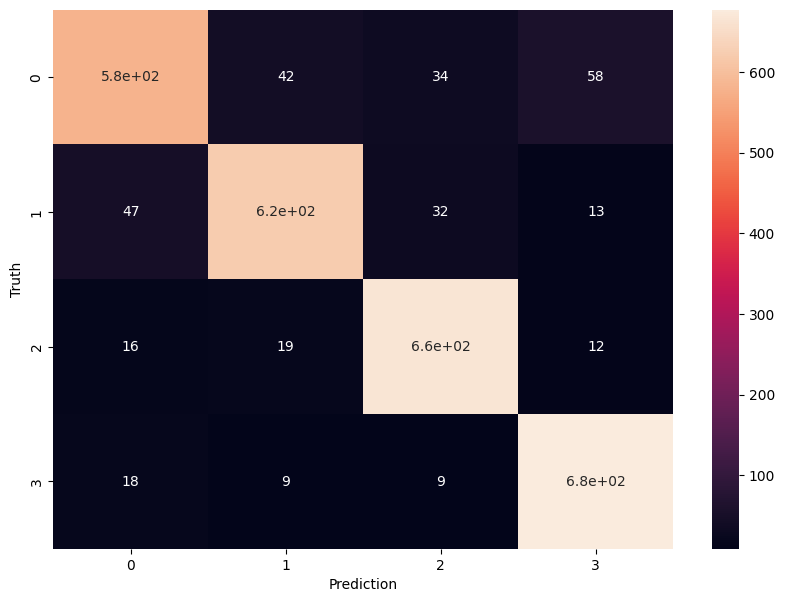

In [ ]:
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Prediction')
plt.ylabel('Truth')

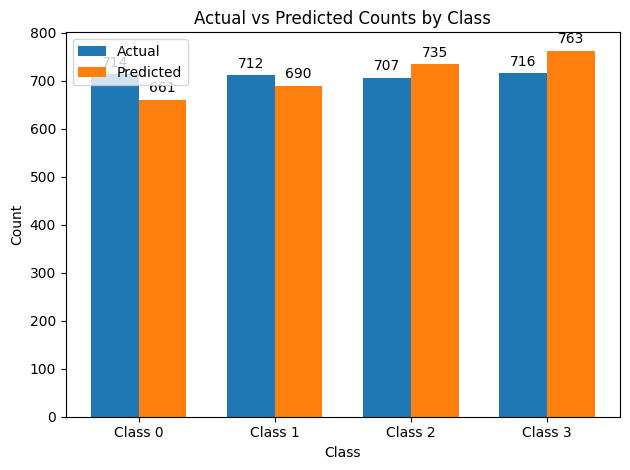

In [ ]:
# Define the confusion matrix
matrix = np.array([
    [580, 42, 34, 58],
    [47, 620, 32, 13],
    [16, 19, 660, 12],
    [18, 9, 9, 680]
])

# Calculate the total actual values for each class
actual_values = matrix.sum(axis=1)

# Calculate the total predicted values for each class
predicted_values = matrix.sum(axis=0)

# Define the class labels
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

# Plot the actual vs. predicted values
x = np.arange(len(class_labels))  # the label locations

fig, ax = plt.subplots()
width = 0.35  # the width of the bars

rects1 = ax.bar(x - width/2, actual_values, width, label='Actual')
rects2 = ax.bar(x + width/2, predicted_values, width, label='Predicted')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Actual vs Predicted Counts by Class')
ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.legend()

# Attach a text label above each bar in rects, displaying its height.
def autolabel(rects):
    """Attach a text label above each bar in rects, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()


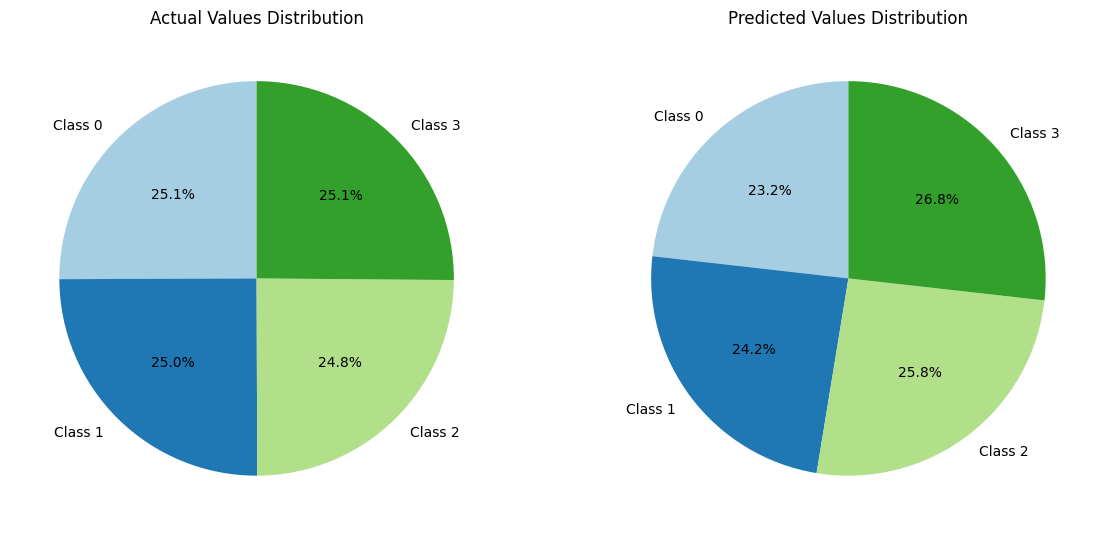

In [ ]:
# Define the confusion matrix
matrix = np.array([
    [580, 42, 34, 58],
    [47, 620, 32, 13],
    [16, 19, 660, 12],
    [18, 9, 9, 680]
])

# Calculate the total actual values for each class
actual_values = matrix.sum(axis=1)

# Calculate the total predicted values for each class
predicted_values = matrix.sum(axis=0)

# Define the class labels
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

# Plot pie charts for actual and predicted values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Actual values pie chart
ax1.pie(actual_values, labels=class_labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
ax1.set_title('Actual Values Distribution')

# Predicted values pie chart
ax2.pie(predicted_values, labels=class_labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
ax2.set_title('Predicted Values Distribution')

plt.show()